# PRÁCTICA 2: TÉCNICAS DE ANÁLISIS

## PARTE 1: REGRESIÓN Y CLASIFICACIÓN

Para la primera parte de la práctica es necesario realizar dos tareas: una de regresión y otra de clasificación. Para ello, se deberá buscar uno o varios datasets por internet que cumplan los requisitos especificados en el siguiente párrafo, así como plantear los objetivos que se pretenden realizar, las visualizaciones a mostrar y las conclusiones extraídas. Puedes utilizar los datasets de la práctica anterior siempre y cuando cumplan con estos requisitos.

Requisitos de las prácticas de regresión/ clasificación:

* El dataset o datasets debe de tener un mínimo de 4 dimensiones, más la variables a predecir (si se usan varios datasets que son unificados en uno solo, el número total de dimensiones debe de ser como mínimo 4) 
* En el caso del clasificador, la clasificación a realizar será del tipo multilabel (debe de tener un mínimo de 3 clases a predecir)
* Se deben usar, al menos, árboles de decisión tanto para clasificación como para regresión

El dataset que hemos escogido para este trabajo es el **OBESITY LEVELS DATASET** (*Estimation of Obesity Levels Based on Eating Habits and Physical Condition*), que se puede encontrar en el UCI Machine Learning Repository.

Contiene 2.111 registros de individuos de México, Perú y Colombia, con 16 variables de hábitos alimenticios, actividad física y condición física, más la etiqueta de nivel de obesidad (`NObeyesdad`), que tiene 7 clases. Aproximadamente el 77% de los datos fueron generados sintéticamente mediante SMOTE a partir de 485 observaciones reales, para equilibrar las clases.

Antes de empezar con el trabajo como tal, hemos decidido realizar un pequeño análisis exploratorio de los datos para ver a qué nos enfrentaremos.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


In [17]:
# Cargamos el dataset de obesidad.
obesity = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

# Mostramos las primeras filas para verificar que se ha cargado correctamente.
print(obesity.shape)
print(obesity.head())

(2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportat

Las columnas de las que disponemos son:

**Datos demográficos y antropométricos**
1. **Gender**: género del individuo (`Female`, `Male`). Categórica.
2. **Age**: edad en años. Numérica.
3. **Height**: altura en metros. Numérica.
4. **Weight**: peso en kilogramos. Numérica. *(Será nuestra variable objetivo en regresión.)*

**Antecedentes e información de hábitos alimenticios**

5. **family_history_with_overweight**: si algún familiar ha tenido sobrepeso (`yes`/`no`). Binaria.
6. **FAVC** (*Frequent consumption of high caloric food*): si consume comida alta en calorías de forma frecuente (`yes`/`no`).
7. **FCVC** (*Frequency of Consumption of Vegetables*): frecuencia de consumo de verduras. Escala 1–3.
8. **NCP** (*Number of main meals*): número de comidas principales al día. Escala 1–4.
9. **CAEC** (*Consumption of food between meals*): frecuencia de picoteo entre horas (`no`, `Sometimes`, `Frequently`, `Always`). Ordinal.
10. **CH2O** (*Daily water consumption*): litros de agua al día. Escala 1–3.
11. **CALC** (*Consumption of alcohol*): frecuencia de consumo de alcohol (`no`, `Sometimes`, `Frequently`, `Always`). Ordinal.

**Estilo de vida y actividad**

12. **SMOKE**: si fuma (`yes`/`no`). Binaria.
13. **SCC** (*Calories consumption monitoring*): si monitoriza las calorías que consume (`yes`/`no`). Binaria.
14. **FAF** (*Physical activity frequency*): frecuencia de actividad física semanal. Escala 0–3.
15. **TUE** (*Time using technology devices*): horas diarias usando dispositivos tecnológicos. Escala 0–2.
16. **MTRANS** (*Transportation used*): medio de transporte habitual (`Automobile`, `Motorbike`, `Bike`, `Public_Transportation`, `Walking`). Categórica.

17. **NObeyesdad**: nivel de obesidad. Tiene 7 clases y será nuestra variable objetivo de clasificación:
    - `Insufficient_Weight`
    - `Normal_Weight`
    - `Overweight_Level_I`
    - `Overweight_Level_II`
    - `Obesity_Type_I`
    - `Obesity_Type_II`
    - `Obesity_Type_III`


In [18]:
# Veamos cuántos individuos hay de cada género.
print(obesity['Gender'].value_counts())

Gender
Male      1068
Female    1043
Name: count, dtype: int64


Están bastante bien equilibradas las clases, lo que hace que sea menos probable que nuestro trabajo caiga en sesgos o descalibres.

In [19]:
# Vamos a cambiar los nombres de las clases para que sean mas legibles.
obesity['NObeyesdad'] = obesity['NObeyesdad'].replace({
    'Insufficient_Weight': 'Insuficiente',
    'Normal_Weight': 'Normal',
    'Overweight_Level_I': 'Sobrepeso I',
    'Overweight_Level_II': 'Sobrepeso II',
    'Obesity_Type_I': 'Obesidad  I',
    'Obesity_Type_II': 'Obesidad II',
    'Obesity_Type_III': 'Obesidad III'
})

# Veamos cuántos individuos hay de cada nivel de obesidad.
print(obesity['NObeyesdad'].value_counts())


NObeyesdad
Obesidad  I     351
Obesidad III    324
Obesidad II     297
Sobrepeso I     290
Sobrepeso II    290
Normal          287
Insuficiente    272
Name: count, dtype: int64


De nuevo, también están relativamente bien equilibradas las clases, lo cual nos facilita el trabajo.

/var/folders/bq/6pxdsh8107s4_tvgz_5dhtj40000gn/T/ipykernel_1857/2271389048.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=obesity, x='NObeyesdad', order=order, palette='viridis')


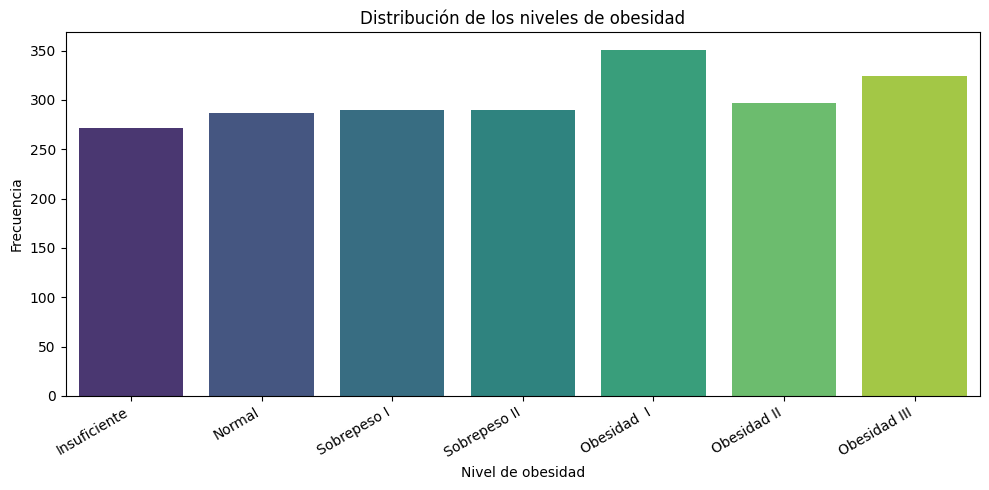

In [20]:
# Visualizamos la distribución de las clases de obesidad.
order = ['Insuficiente', 'Normal', 'Sobrepeso I', 'Sobrepeso II', 'Obesidad  I', 'Obesidad II', 'Obesidad III']

plt.figure(figsize=(10,5))
sns.countplot(data=obesity, x='NObeyesdad', order=order, palette='viridis')
plt.title('Distribución de los niveles de obesidad')
plt.xlabel('Nivel de obesidad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Las clases están **bastante equilibradas** (entre ~270 y ~350 muestras cada una), lo cual es consecuencia del proceso de balanceo mediante SMOTE aplicado por los autores del dataset. Esto es una gran ventaja para nuestros modelos de clasificación y de ensembles, ya que no necesitaremos aplicar técnicas de resampling adicionales.

El género también está repartido de forma razonablemente equilibrada (~50/50).

Vamos a seguir con un pequeño análisis exploratorio y de correlación entre las variables clave.

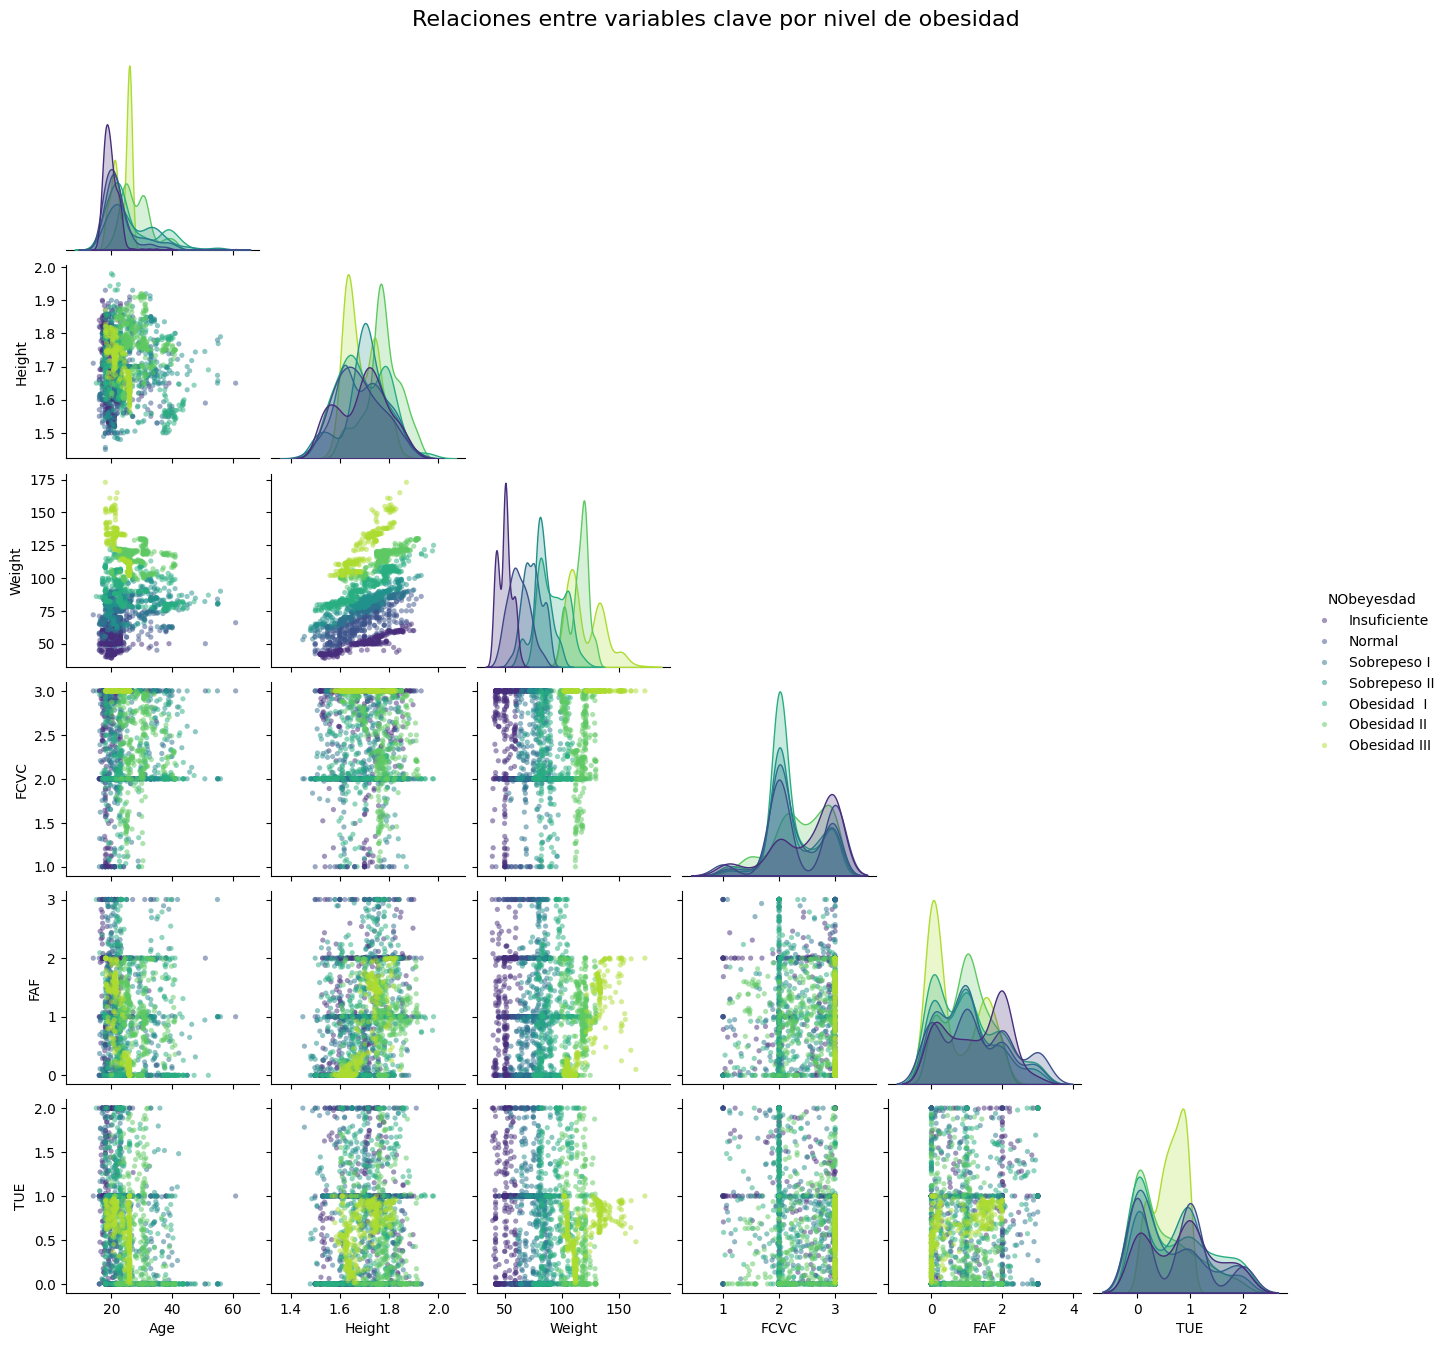

In [21]:
# Seleccionamos las variables numéricas clave para el análisis visual.
vars_key = [
    "Age",     # edad: buen discriminador entre clases jóvenes / mayores
    "Height",  # altura: complementa peso para entender BMI
    "Weight",  # variable objetivo de regresión, principal correlato con la etiqueta
    "FCVC",    # consumo de verduras
    "FAF",     # frecuencia de actividad física
    "TUE",     # tiempo frente a pantallas
]

order = ['Insuficiente', 'Normal', 'Sobrepeso I', 'Sobrepeso II', 'Obesidad  I', 'Obesidad II', 'Obesidad III']

sns.pairplot(
    obesity.dropna(),
    vars=vars_key,
    hue="NObeyesdad",
    hue_order=order,
    diag_kind="kde",
    kind="scatter",
    height=2.2,
    plot_kws={"alpha": 0.5, "s": 14, "edgecolor": "none"},
    corner=True,
    palette="viridis",
)
plt.suptitle("Relaciones entre variables clave por nivel de obesidad", y=1.02, fontsize=16)
plt.show()

Como podemos ver en el pairplot:

* **`Weight`** es, con diferencia, la variable que mejor separa las clases: las KDE de la diagonal muestran picos claramente ordenados de `Insuficiente` (≈45 kg) hasta `Obesidad III` (≈115 kg). Esto es esperable ya que la etiqueta se construye a partir del IMC, que depende directamente del peso.
* **`Height`** tiene distribuciones muy solapadas entre clases; por sí sola aporta poca información, pero combinada con `Weight` define el IMC.
* **`Age`** muestra que las clases de obesidad severa (Tipos II y III) se concentran en edades algo mayores, mientras que `Insuficiente` está sesgada hacia individuos más jóvenes.
* **`FAF` (actividad física)** tiende a ser mayor en clases de peso normal o insuficiente y menor en obesidad tipo III, aunque con bastante solapamiento.
* **`FCVC` (consumo de verduras)** y **`TUE` (tiempo de pantalla)** son mucho más ruidosas y no separan bien las clases por sí solas.

El par **`Weight` vs `Height`** dibuja claramente las curvas de nivel del IMC, con las clases apareciendo como bandas diagonales. Es el par más discriminativo. Esto nos indica que un modelo simple basado en estas dos variables ya conseguirá una tasa de acierto alta, pero también que gran parte del reto de la práctica está en **predecir el nivel de obesidad sin usar `Weight` y `Height`** (es decir, solo a partir de hábitos), que es donde aparecen patrones realmente interesantes.


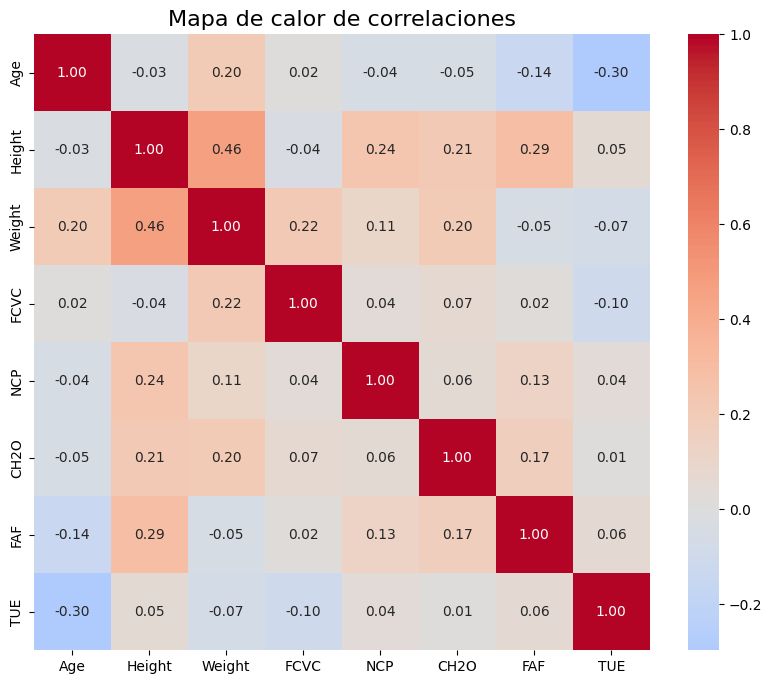

In [22]:
# Mapa de calor de correlaciones entre variables numéricas.
num_cols = obesity.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10,8))
sns.heatmap(obesity[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True)
plt.title("Mapa de calor de correlaciones", fontsize=16)
plt.show()

En general, no hya ninguna correlación alta como tal, porque ninguna supera el 0.5.
Si tuvierámos que mencionar algunas entre las variables numéricas diríamos:

* **`Weight` vs `Height`** (≈0.46): correlación positiva moderada, coherente (las personas más altas tienden a pesar más), y es la base sobre la que se construye el IMC.
* **`Age` vs `Weight`** (≈0.20): ligera correlación positiva; el peso tiende a aumentar con la edad en este dataset.
* **`TUE` (tiempo de pantallas) vs `Age`** (≈-0.30): los individuos jóvenes pasan más tiempo delante de dispositivos tecnológicos.
* **`FAF` vs `Height`** (≈0.29): ligera correlación positiva, lo cual tampoco nos dice mucho porque que a mayor altura mayor actividad física. no tiene mucho sentido real.
* Las variables de hábitos (`FCVC`, `NCP`, `CH2O`, `FAF`, `TUE`) tienen **correlaciones lineales bajas entre sí**, lo que indica que capturan dimensiones relativamente independientes del estilo de vida. Esto es una buena noticia para los modelos no lineales (árboles, ensembles), que podrán explotar interacciones.

Este heatmap solo considera las variables numéricas. Variables categóricas importantes como `family_history_with_overweight`, `CAEC`, `CALC` o `MTRANS` requerirán un tratamiento aparte (codificación ordinal o one-hot) antes de entrar en los modelos, y analizaremos su relación con la etiqueta mediante tablas de contingencia o gráficos de barras apiladas más adelante.


PREPROCESAMIENTO DE LAS VARIABLES:

In [23]:
# La variable objetivo es NObeyesdad, que es categórica ordinal. Vamos a convertirla a numérica para facilitar el análisis.
obesity = pd.DataFrame(obesity)
obesity['NObeyesdad'] = obesity['NObeyesdad'].map({
    'Insuficiente': -1,
    'Normal': 0,
    'Sobrepeso I': 1,
    'Sobrepeso II': 2,
    'Obesidad  I': 3,
    'Obesidad II': 4,
    'Obesidad III': 5
})  

# También queremos convertir a escalas las variables CAE y CALC, que son ordinales.
ordinal_cols = ["CAEC", "CALC"]
for col in ordinal_cols:
    obesity[col] = obesity[col].map({
        "no": 0,
        "Sometimes": 1,
        "Frequently": 2,
        "Always": 3
    })

# Convertimos sexo a 0= Male y 1 = Female
obesity['Gender'] = obesity['Gender'].map({'Male': 0, 'Female': 1})

# Hacemos la misma transformación para las variables binarias.
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"no": 0, "yes": 1})

# One-hot para la única categórica nominal (sin orden): MTRANS ---
obesity = pd.get_dummies(obesity, columns=["MTRANS"], prefix="MTRANS", drop_first=False, dtype=int)

print(obesity.head())

   Gender   Age  Height  Weight  family_history_with_overweight  FAVC  FCVC  \
0       1  21.0    1.62    64.0                               1     0   2.0   
1       1  21.0    1.52    56.0                               1     0   3.0   
2       0  23.0    1.80    77.0                               1     0   2.0   
3       0  27.0    1.80    87.0                               0     0   3.0   
4       0  22.0    1.78    89.8                               0     0   2.0   

   NCP  CAEC  SMOKE  ...  SCC  FAF  TUE  CALC  NObeyesdad  MTRANS_Automobile  \
0  3.0     1      0  ...    0  0.0  1.0     0           0                  0   
1  3.0     1      1  ...    1  3.0  0.0     1           0                  0   
2  3.0     1      0  ...    0  2.0  1.0     2           0                  0   
3  3.0     1      0  ...    0  2.0  0.0     2           1                  0   
4  1.0     1      0  ...    0  0.0  0.0     1           2                  0   

   MTRANS_Bike  MTRANS_Motorbike  MTRANS_Pub

## PARTE 2: ENSEMBLES Y CLUSTERING

Para la segunda parte de la práctica es necesario realizar de forma obligatoria dos tareas: una de ensembles y otra de clustering. 
Para ello, se deberá buscar uno o varios datasets por internet que cumplan los requisitos especificados en el siguiente párrafo, así como plantear los objetivos que se pretenden realizar, las visualizaciones a mostrar y las conclusiones extraídas.

Requisitos de la segunda parte:

* El dataset o datasets de ensembles podrá ser el mismo que el utilizado para clasificación.
* El dataset o datasets de clustering debe de tener un mínimo de 3 dimensiones.
* En el caso del ensemble, la clasificación a realizar será de igual forma que en la parte anterior del tipo multilabel (debe de tener un mínimo de 3 clases a predecir).

Vamos a comenzar haciendo un clustering sobre las variables de hábitos de los individuos, para ver si emergen perfiles de estilo de vida independientemente de la etiqueta de obesidad, y compararlos después con `NObeyesdad`.

Vamos a comenzar aplicando el algoritmo de las K medias para las variables de hábitos: 
* family_history_with_overweight
* FAVC
* FCVC
* NCP
* CAEC
* SMOKE
* CH20
* SCC
* FAF
* TUE
* CALC 

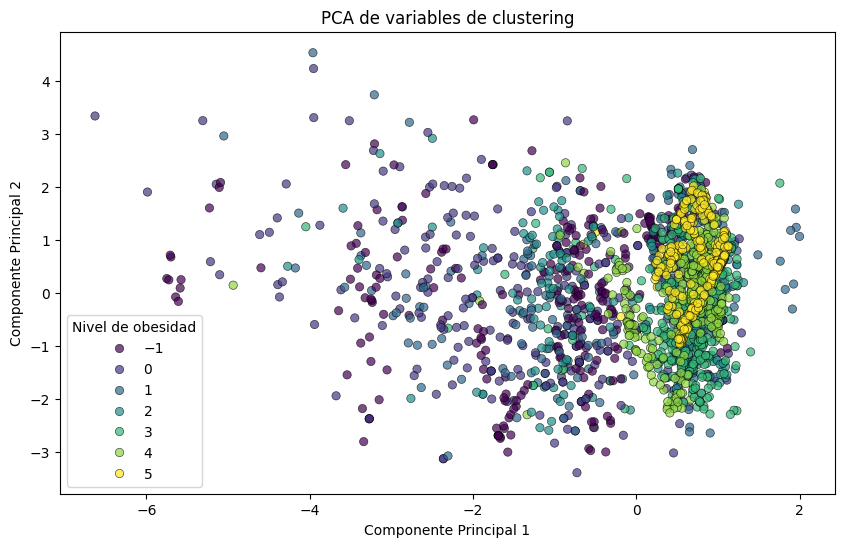

In [24]:
clustering_vars = [
    "family_history_with_overweight",  # binaria 0/1
    "FAVC",                            # binaria 0/1
    "FCVC",                            # escala 1-3
    "NCP",                             # escala 1-4
    "CAEC",                            # ordinal 0-3
    "SMOKE",                           # binaria 0/1
    "CH2O",                            # escala 1-3
    "SCC",                             # binaria 0/1
    "FAF",                             # escala 0-3
    "TUE",                             # escala 0-2
    "CALC",                            # ordinal 0-3
]

Y = obesity['NObeyesdad']

# Primero hacemos un PCA para reducir dimensionalidad y visualizar mejor las relaciones entre individuos antes de clusterizar.

X_scaled = StandardScaler().fit_transform(obesity[clustering_vars].copy())
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) 
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=Y, palette='viridis', alpha=0.7, edgecolor='k')
plt.title('PCA de variables de clustering')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Nivel de obesidad')
plt.show()


Como podemos ver, antes de aplicar el algoritmo de las K medias, no se pueden desagrupar muy bien los clusters pero sí que se pueden sacar algunas conclusiones. 

Parece como que a mayor nivel de obesidad más a la derecha de la primera componente principal se sitúan los individuos y viceversa.

Veámos a partir de qué variables se crea cada componente.

In [25]:
# Veámos de qué está fromada cada componente principal para entender qué variables están más relacionadas con cada eje.
pca_components = pd.DataFrame(pca.components_, columns=clustering_vars, index=['PC1', 'PC2'])
print(pca_components)   

     family_history_with_overweight      FAVC      FCVC       NCP      CAEC  \
PC1                        0.500193  0.505808 -0.066002 -0.019039 -0.441485   
PC2                        0.184649 -0.101338  0.309077  0.440145 -0.040404   

        SMOKE      CH2O       SCC       FAF       TUE      CALC  
PC1 -0.106291  0.198947 -0.442386 -0.185167  0.034219  0.110890  
PC2  0.070765  0.585347  0.139927  0.519844  0.031986  0.162073  


La primera está conformada sobre todo por las variables family_history y FAVC en positivo y CAEC y SCC en negativo.

Mientras que la segunda está conformada sobre todo por las variables NCP, CH20. FAF  FCVC.

Con esta información podemos discurrir las siguientes hipótesis:

1. La PC1 está relacionada con un "eje de riesgo estructurado" porque define un perfil de predisposición + una dieta calórica sin control. consciente, pero con estructura de comidas fija (porque no hay picoteo entre horas).
    * Así, los individuos con un PC1 alto son aquellos con el estilo tradicional de riesgo de obesidad: carga genética que comen fuerte, no pican entre hroas pero tampoco cuentan las calorías.
    * Los individuos con un PC1 bajo no tienen antecedentes familiares y presentan una dieta menos calórica, aunque sí que picotean y también cuentan las calorías. Por tanto, es un perfil más consciente pero picoteador.

2. La PC2 parece más bien un eje de actividad/ calidad de la alimentación, con FAF, CH20 y FCVC. Sería un eje que separa:
    * Extremo activo y consciente: pratica deporte, come verduras en sus 3-4 comidas y bebe mucha agua.
    * Extremo sedentario: poca actividad, pocas comidas/verduras y poca agua.

Veámos cuánta de la varianza son capaces de explicar estas 2 componentes principales:

In [26]:
# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {explained_variance[0]:.2f}")
print(f"Varianza explicada por PC2: {explained_variance[1]:.2f}")   

# Varianza explicada conjuntamente por ambos componentes
total_explained_variance = explained_variance.sum()
print(f"Varianza explicada por PC1 y PC2 conjuntamente: {total_explained_variance:.2f}")    


Varianza explicada por PC1: 0.14
Varianza explicada por PC2: 0.12
Varianza explicada por PC1 y PC2 conjuntamente: 0.26


Por tanto, como vemos, 2 componentes no es suficiente para explicar ni la mitad de la varianza. Vamos a aplicar la regla del codo para ver con cuántas componentes principales lograríamos explicar al menos el 80% de la varianza.

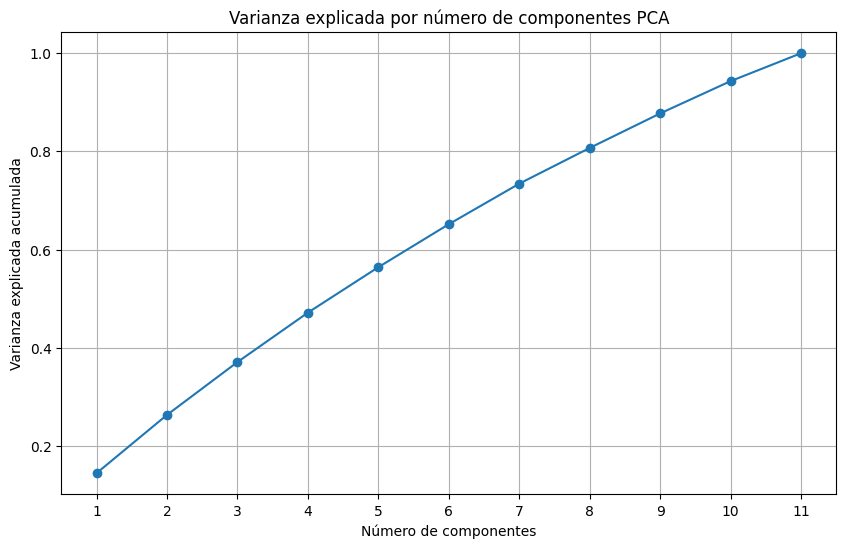

In [27]:
x = np.arange(1, 12)
varianza_explicada = []
for i in range(1, 12):
    pca = PCA(n_components=i)
    X_pca = pca.fit_transform(X_scaled) 
    # Varianza total explicada por los primeros i componentes
    explained_variance = pca.explained_variance_ratio_.sum()
    varianza_explicada.append(explained_variance)

# Graficamos:
plt.figure(figsize=(10,6))
plt.plot(x, varianza_explicada, marker='o')
plt.title('Varianza explicada por número de componentes PCA')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.xticks(x)
plt.grid()
plt.show()

Con 8 componentes ya explicaríamos un poco más del 80% de la varianza.

No obstante, 8 componentes es bastante. Es por esto que el PCA no es el método más eficiente para clusterizar usando nuestro dataset.

Ahora sí vamos con el algoritmo de las K medias que usaremos también para comparar con estos resultados previos.

In [ ]:
X = obesity[clustering_vars].values

# De nuevo es importante escalar antes de aplicar el algoritmo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Queremos 7 clusters. uno por cada clase de obesidad.
k = 7
kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Comparamos con la etiqueta real
ari = adjusted_rand_score(obesity["NObeyesdad"], clusters)
print(f"ARI vs NObeyesdad: {ari:.3f}")


ARI vs NObeyesdad: 0.184


El ARI o Adjusted Rand Index mide el parecido entre 2 particiones del mismo conjunto, en este caso los clusters del KMeans y los clusters reales de NObeyesidad.

Es una medida que toma valores hasta el 1, siendo el 0 coincidencias al nivel del azar, por lo que un ARI = 0.184 es un poco débil. Los clusters no recuperan las 7 clases de obesidad, aunque capturan algo de estructura relacionada.

Ve´